<a href="https://colab.research.google.com/github/SruthiGS-Gito/Assessment_1/blob/main/Assessment_2_Heart_Disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ASSESSMENT ON HEART DISEASE

▶ Features and Target Description
* age : Age of the individual
* sex : Gender of the individual (0 = female, 1 = male)
* chest pain type : Type of chest pain (4 categories: 0-3)
* resting blood pressure : Resting blood pressure (in mm Hg)
* serum cholesterol : Cholesterol level (in mg/dl)
* fasting blood sugar : Fasting blood sugar > 120 mg/dl (1 = true, 0 = false)
* resting electrocardiographic results : ECG results (0 = normal, 1 = ST-T abnormality, 2 = probable/definite left ventricular hypertrophy)
* maximum heart rate achieved
* exercise induced angina : Exercise-induced chest pain (1 = yes, 0 = no)
* oldpeak : ST depression induced by exercise relative to rest
* slope : The slope of the peak exercise ST segment (0-2)
* number of major vessels : Number of major vessels (0-3) colored by fluoroscopy
* thal : Type of thalassemia (0 = normal, 1 = fixed defect, 2 = reversible defect)
* target : Presence of heart disease (1 = Yes, 0 = No) (for classifcation) and serum cholesterol (for regression)

## ▶ Importing necessary Libraries

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif # Target is whether heart disease [yes or no], so classification

from sklearn.model_selection import train_test_split

## ▶ Loading & Reading the Dataset


In [13]:
heart_df = pd.read_csv("/content/drive/MyDrive/AI ML/ICT_AI_ML/student_manager/data/heart_disease.csv")

In [14]:
heart_df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


## ▶ EDA

In [15]:
heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [16]:
heart_df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [17]:
heart_df.shape

(1025, 14)

In [18]:
heart_df.isna().sum()   # Checking for NULL Values, no null values

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [19]:
heart_df.duplicated().sum()

np.int64(723)

In [20]:
heart_df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
1020,True
1021,True
1022,True
1023,True


In [22]:
heart_df = heart_df.drop_duplicates()   # Dopping the duplicates only

In [23]:
heart_df.shape  # For confirmation

(302, 14)

In [24]:
heart_df.duplicated().sum()  # For confirmation

np.int64(0)

## ▶ Boxplot Representation for Outlier Detection

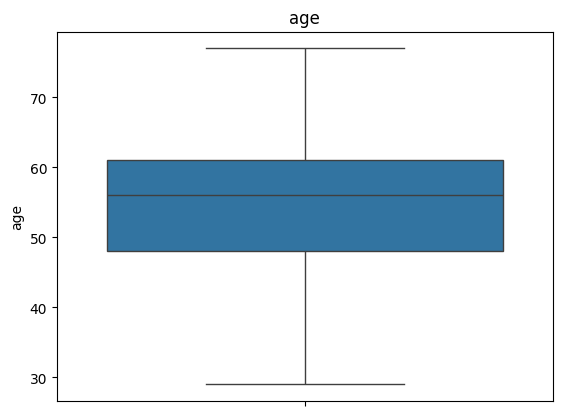

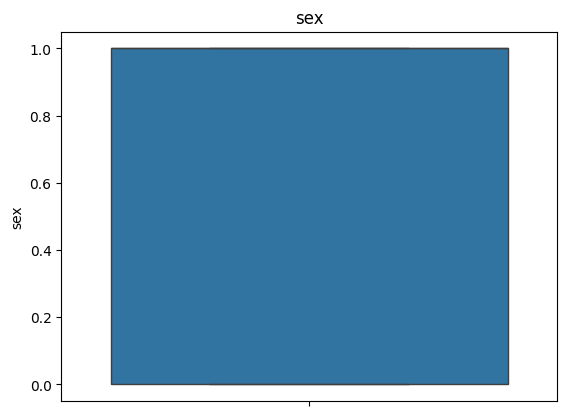

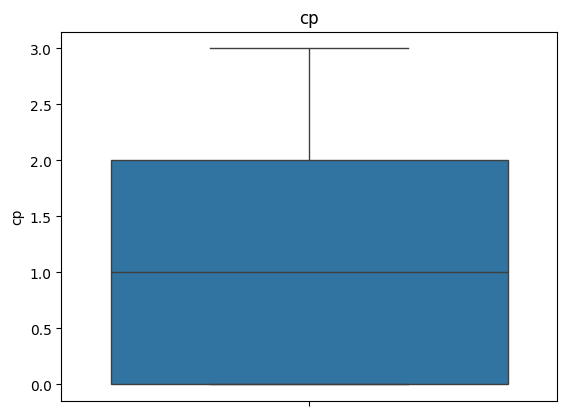

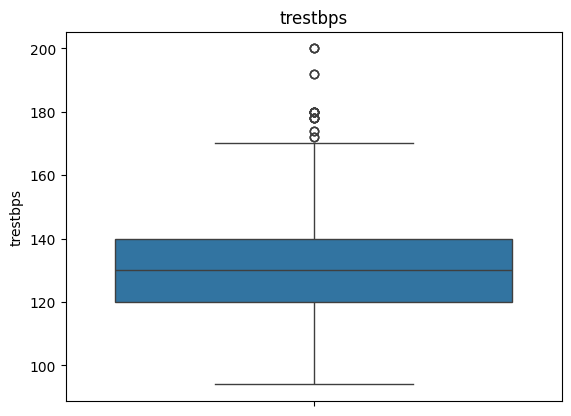

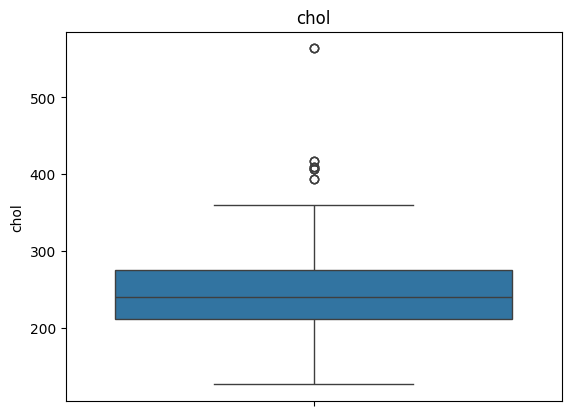

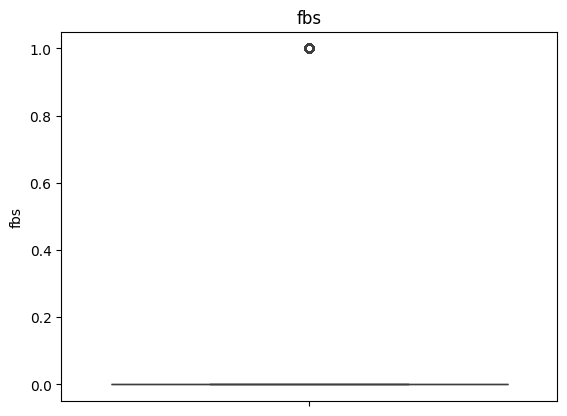

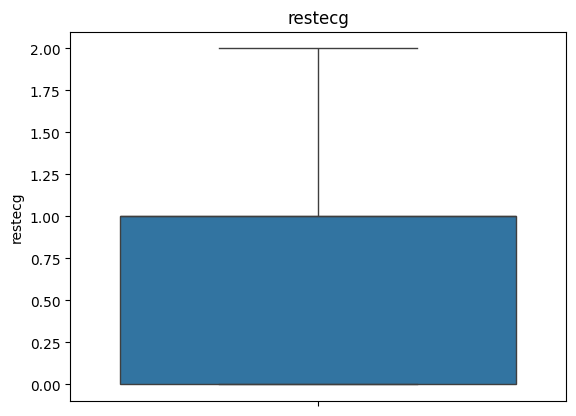

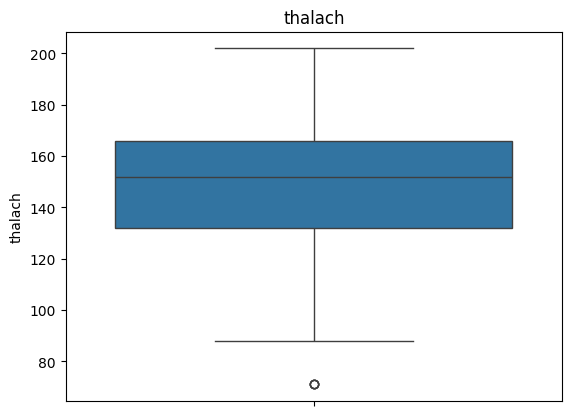

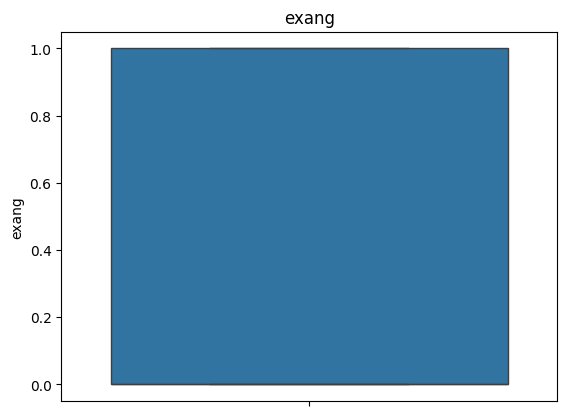

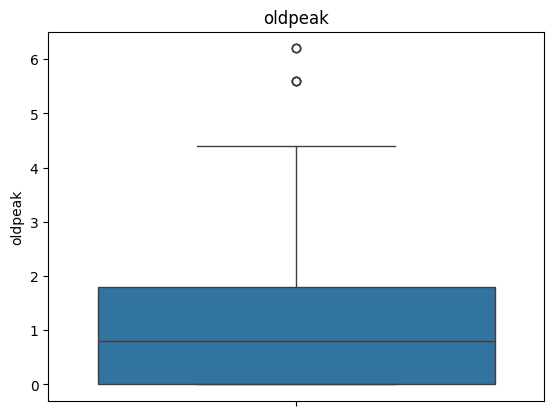

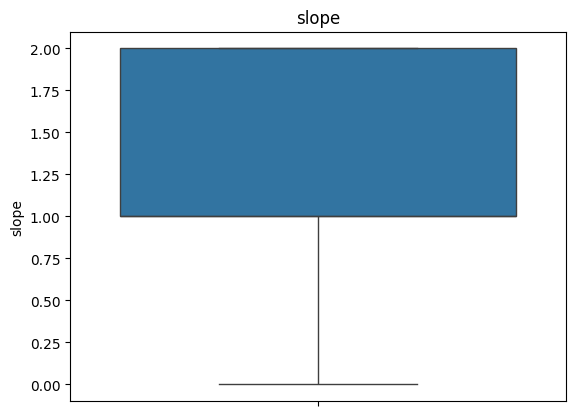

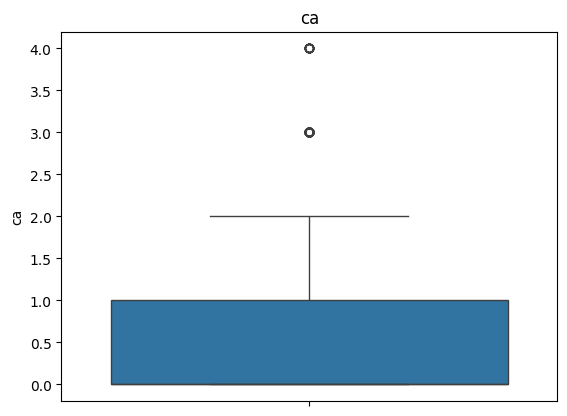

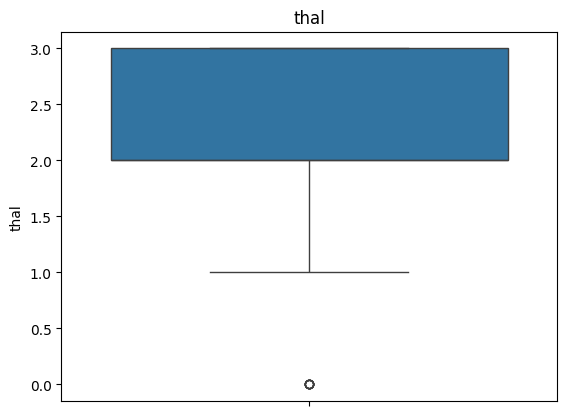

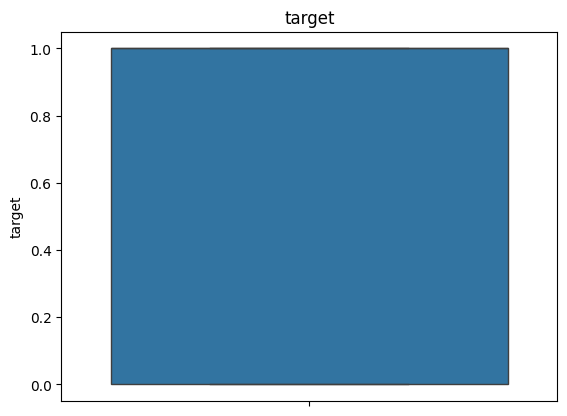

In [21]:
for columns in heart_df:
  sns.boxplot(heart_df[columns])
  plt.title(columns)
  plt.show()

In [21]:
# Features (6/14) : "ca", "oldpeak", "thalach", "fbs", "chol", "trestbps" - Have outliers
# But in medicine values can have extreme values,

## ▶ Correlation Matrix
* Helps to find relationship between all features to target individually

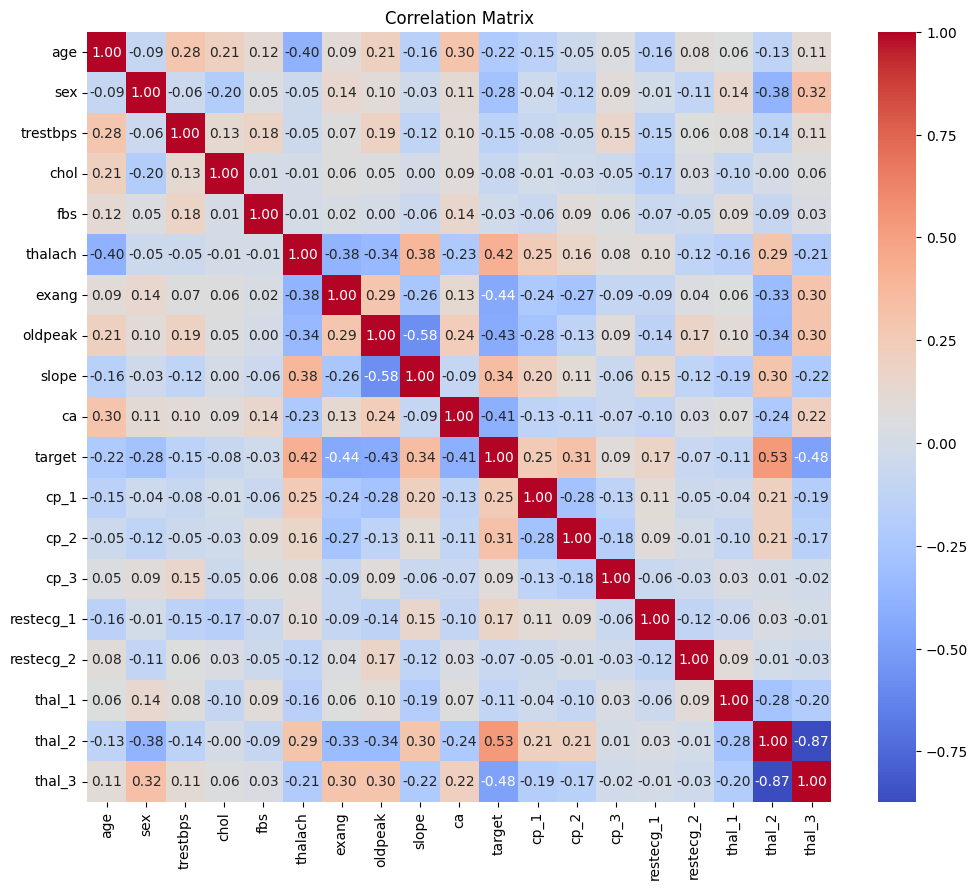

In [33]:
plt.figure(figsize=(12,10))
sns.heatmap(heart_df.corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
# no major multicolinearity

In [31]:
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

for col in numeric_cols:
    Q1 = heart_df[col].quantile(0.25)
    Q3 = heart_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = heart_df[(heart_df[col] < lower) | (heart_df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

age: 0 outliers
trestbps: 9 outliers
chol: 5 outliers
thalach: 1 outliers
oldpeak: 5 outliers


## ▶ Data Cleaning

### ▶ Encoding
◼ One-Hot Encoding : multi-category variables (chest pain type, resting electrocardiographic results, thal).

◼ Binary Encoding : sex and fasting blood sugar. (Already encoded)

In [25]:
# One-Hot Encoding
categorical_cols = ['cp', 'restecg', 'thal']
heart_df = pd.get_dummies(heart_df, columns=categorical_cols, drop_first=True)

heart_df.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,thal_1,thal_2,thal_3
0,52,1,125,212,0,168,0,1.0,2,2,0,False,False,False,True,False,False,False,True
1,53,1,140,203,1,155,1,3.1,0,0,0,False,False,False,False,False,False,False,True
2,70,1,145,174,0,125,1,2.6,0,0,0,False,False,False,True,False,False,False,True
3,61,1,148,203,0,161,0,0.0,2,1,0,False,False,False,True,False,False,False,True
4,62,0,138,294,1,106,0,1.9,1,3,0,False,False,False,True,False,False,True,False


In [29]:
# Encoded columns have boolean values hence changing it to numerical
dummy_cols = ['cp_1', 'cp_2', 'cp_3','restecg_1', 'restecg_2','thal_1', 'thal_2', 'thal_3']
heart_df[dummy_cols] = heart_df[dummy_cols].astype(int)

heart_df.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,thal_1,thal_2,thal_3
0,52,1,-0.376556,-0.667728,0,0.806035,0,-0.037124,2,2,0,0,0,0,1,0,0,0,1
1,53,1,0.478910,-0.841918,1,0.237495,1,1.773958,0,0,0,0,0,0,0,0,0,0,1
2,70,1,0.764066,-1.403197,0,-1.074521,1,1.342748,0,0,0,0,0,0,1,0,0,0,1
3,61,1,0.935159,-0.841918,0,0.499898,0,-0.899544,2,1,0,0,0,0,1,0,0,0,1
4,62,0,0.364848,0.919336,1,-1.905464,0,0.739054,1,3,0,0,0,0,1,0,0,1,0


In [26]:
heart_df.columns

Index(['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak',
       'slope', 'ca', 'target', 'cp_1', 'cp_2', 'cp_3', 'restecg_1',
       'restecg_2', 'thal_1', 'thal_2', 'thal_3'],
      dtype='object')

### ▶ Scaling Numerical Features
◼ Features : "resting blood pressure", "serum cholesterol", "maximum heart rate", "oldpeak" [ StandardScaler or MinMaxScaler ]

In [ ]:
# StandardScalar : Transforming the data so that : Mean = 0 & Standard Deviation = 1,
# Min-max scalar : super sensitive to outliers, one unusually large value stretches the entire scale

In [28]:
scaler = StandardScaler()

numerical_cols = ['trestbps', 'chol', 'thalach', 'oldpeak']
heart_df[numerical_cols] = scaler.fit_transform(heart_df[numerical_cols])

heart_df.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,thal_1,thal_2,thal_3
0,52,1,-0.376556,-0.667728,0,0.806035,0,-0.037124,2,2,0,False,False,False,True,False,False,False,True
1,53,1,0.478910,-0.841918,1,0.237495,1,1.773958,0,0,0,False,False,False,False,False,False,False,True
2,70,1,0.764066,-1.403197,0,-1.074521,1,1.342748,0,0,0,False,False,False,True,False,False,False,True
3,61,1,0.935159,-0.841918,0,0.499898,0,-0.899544,2,1,0,False,False,False,True,False,False,False,True
4,62,0,0.364848,0.919336,1,-1.905464,0,0.739054,1,3,0,False,False,False,True,False,False,True,False


## ▶ Train-Test Split

### ▶ For Regression : Predicting "serum cholesterol" as the target variable and remaining as features

In [38]:
# Features and Target for Regression
X_reg = heart_df.drop('chol', axis=1)
y_reg = heart_df['chol']

# Train-Test Split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

### ▶ For Classification : Predicting target (presence of heart disease) as the target variable and remaining as features

In [39]:
# Features and Target for Classification
X_clf = heart_df.drop('target', axis=1)
y_clf = heart_df['target']

# Train-Test Split
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

## ▶ Build Machine Learning Models

### ▶ Linear Regression
### Regression Task : Train the following models to predict serum cholesterol, Linear regression, SVM, Random Forest